# DriveGuardAI — Complete Capstone 2
## ML-Based Intrusion Detection in Vehicular Networks
**CICIoV2024 | LR · RF · AdaBoost · DNN | SHAP · LIME | Multi-Format | Multi-Class | Live Dashboard**

## Cell 0 — Mount Drive & Set Paths

In [13]:
from google.colab import drive
drive.mount('/content/drive')
import os

BASE_PATH = '/content/drive/MyDrive/DriveGuardAI_Dataset/CICIOV dataset'
DECIMAL_PATH = os.path.join(BASE_PATH, 'decimal')
HEX_PATH     = os.path.join(BASE_PATH, 'hexadecimal')
BINARY_PATH  = os.path.join(BASE_PATH, 'binary')
OUTPUT_DIR = '/content/drive/MyDrive/DriveGuardAI_Output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

for lbl, p in [('Decimal', DECIMAL_PATH), ('Hex', HEX_PATH), ('Binary', BINARY_PATH)]:
    print(f'{lbl:12s} {p}  ->  {"EXISTS" if os.path.isdir(p) else "NOT FOUND"}')
    if os.path.isdir(p):
        for f in sorted(os.listdir(p)):
            if f.endswith('.csv'): print(f'             {f}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Decimal      /content/drive/MyDrive/DriveGuardAI_Dataset/CICIOV dataset/decimal  ->  EXISTS
             decimal_DoS.csv
             decimal_benign.csv
             decimal_spoofing-GAS.csv
             decimal_spoofing-RPM.csv
             decimal_spoofing-SPEED.csv
             decimal_spoofing-STEERING_WHEEL.csv
Hex          /content/drive/MyDrive/DriveGuardAI_Dataset/CICIOV dataset/hexadecimal  ->  EXISTS
             hexadecimal_DoS.csv
             hexadecimal_benign.csv
             hexadecimal_spoofing-GAS.csv
             hexadecimal_spoofing-RPM.csv
             hexadecimal_spoofing-SPEED.csv
             hexadecimal_spoofing-STEERING_WHEEL.csv
Binary       /content/drive/MyDrive/DriveGuardAI_Dataset/CICIOV dataset/binary  ->  EXISTS
             binary_DoS.csv
             binary_benign.csv
             binary_spoofing-GAS.csv
             binary_

## Cell 1 — Install & Import

In [14]:
%%capture
!pip install shap lime imbalanced-learn flask flask-cors pyngrok

import os, time, warnings, json, threading
import pandas as pd
import numpy as np
import joblib
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, auc, roc_auc_score)
from imblearn.over_sampling import SMOTE
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
import shap
import lime
from lime.lime_tabular import LimeTabularExplainer
print('All imports successful.')

---
## PART A — DATA LOADING & PREPROCESSING
---

## Cell 2 — Load Decimal Dataset

In [15]:
def load_decimal_dataset(folder_path):

    attack_frames = []
    benign_frames = []

    for fname in sorted(os.listdir(folder_path)):
        if not fname.endswith('.csv'): continue
        tmp = pd.read_csv(os.path.join(folder_path, fname))
        tmp['source_file'] = fname.replace('.csv', '').replace('decimal_', '')

        if 'benign' in fname.lower():
            benign_frames.append(tmp)
        else:
            attack_frames.append(tmp)
        print(f'  loaded: {fname:40s}  rows={len(tmp):>10,}')

    df_attack = pd.concat(attack_frames, ignore_index=True)
    df_benign = pd.concat(benign_frames, ignore_index=True)

    print(f'\nAttack total: {len(df_attack):,}')
    print(f'Benign total: {len(df_benign):,}')


    drop_cols = ['ID', 'category', 'specific_class']
    for c in drop_cols:
        if c in df_attack.columns: df_attack = df_attack.drop(columns=[c])
        if c in df_benign.columns: df_benign = df_benign.drop(columns=[c])
    print(f'Dropped columns: {drop_cols}')


    data_cols = ['DATA_0','DATA_1','DATA_2','DATA_3','DATA_4','DATA_5','DATA_6','DATA_7']
    for c in data_cols:
        if c in df_attack.columns:
            df_attack[c] = pd.to_numeric(df_attack[c], errors='coerce')
            df_benign[c] = pd.to_numeric(df_benign[c], errors='coerce')


    df_attack.dropna(subset=[c for c in data_cols if c in df_attack.columns], inplace=True)
    df_benign.dropna(subset=[c for c in data_cols if c in df_benign.columns], inplace=True)




    data = pd.concat([df_benign, df_attack], ignore_index=True)

    print(f'\nFinal dataset: {len(data):,} rows')
    print(f'\nClass distribution:')
    print(data['source_file'].value_counts())
    return data

df = load_decimal_dataset(DECIMAL_PATH)
print(f'\nShape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head()

  loaded: decimal_DoS.csv                           rows=    74,663
  loaded: decimal_benign.csv                        rows= 1,223,737
  loaded: decimal_spoofing-GAS.csv                  rows=     9,991
  loaded: decimal_spoofing-RPM.csv                  rows=    54,900
  loaded: decimal_spoofing-SPEED.csv                rows=    24,951
  loaded: decimal_spoofing-STEERING_WHEEL.csv       rows=    19,977

Attack total: 184,482
Benign total: 1,223,737
Dropped columns: ['ID', 'category', 'specific_class']

Final dataset: 1,408,219 rows

Class distribution:
source_file
benign                     1223737
DoS                          74663
spoofing-RPM                 54900
spoofing-SPEED               24951
spoofing-STEERING_WHEEL      19977
spoofing-GAS                  9991
Name: count, dtype: int64

Shape: (1408219, 10)
Columns: ['DATA_0', 'DATA_1', 'DATA_2', 'DATA_3', 'DATA_4', 'DATA_5', 'DATA_6', 'DATA_7', 'label', 'source_file']


,DATA_0,DATA_1,DATA_2,DATA_3,DATA_4,DATA_5,DATA_6,DATA_7,label,source_file
0,96,0,0,0,0,0,0,0,BENIGN,benign
1,132,13,160,0,0,0,0,0,BENIGN,benign
2,127,255,127,255,127,255,127,255,BENIGN,benign
3,15,224,0,0,0,0,0,0,BENIGN,benign
4,1,0,39,16,0,0,0,0,BENIGN,benign


## Cell 3 — Create Labels

In [16]:
if 'label' in df.columns:
    if df['label'].dtype == object:
        df['is_malicious'] = (df['label'].str.lower() != 'benign').astype(int)
    else:
        df['is_malicious'] = df['label'].astype(int)
else:
    df['is_malicious'] = df['source_file'].apply(lambda x: 0 if 'benign' in x.lower() else 1)

if 'category' in df.columns:
    df['attack_type'] = df['category']
elif 'specific_class' in df.columns:
    df['attack_type'] = df['specific_class']
else:
    df['attack_type'] = df['source_file']

print('Binary distribution:')
print(df['is_malicious'].value_counts())
print('\nMulti-class distribution:')
print(df['attack_type'].value_counts())

Binary distribution:
is_malicious
0    1223737
1     184482
Name: count, dtype: int64

Multi-class distribution:
attack_type
benign                     1223737
DoS                          74663
spoofing-RPM                 54900
spoofing-SPEED               24951
spoofing-STEERING_WHEEL      19977
spoofing-GAS                  9991
Name: count, dtype: int64


## Cell 4 — Temporal Features

In [17]:
def add_temporal_features(data):
    for col in ['Timestamp', 'Time']:
        if col in data.columns:
            data = data.sort_values(by=col).reset_index(drop=True)
            data['time_delta'] = data[col].diff().fillna(0)
            print(f'time_delta from {col}')
            return data
    # No timestamp and no ID (we dropped it), use simple row sequence
    data['time_delta'] = data.index.to_series().diff().fillna(0)
    print('time_delta from row sequence')
    return data

df = add_temporal_features(df)

time_delta from row sequence


## Cell 5 — Feature Selection, Scaling, Split

In [18]:

FEATURE_COLS = ['DATA_0','DATA_1','DATA_2','DATA_3','DATA_4','DATA_5','DATA_6','DATA_7','time_delta']

available = [c for c in FEATURE_COLS if c in df.columns]
print(f'Features ({len(available)}): {available}')

X = df[available].copy()
y_binary = df['is_malicious'].copy()
y_multi = df['attack_type'].copy()

le = LabelEncoder()
y_multi_enc = le.fit_transform(y_multi)
class_names = le.classes_.tolist()
print(f'Classes ({len(class_names)}): {class_names}')

scaler = MinMaxScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=available)

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_scaled, y_binary, test_size=0.2, random_state=42, stratify=y_binary)
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_scaled, y_multi_enc, test_size=0.2, random_state=42, stratify=y_multi_enc)
print(f'Binary  - Train:{len(X_train_b):,} Test:{len(X_test_b):,}')
print(f'Multi   - Train:{len(X_train_m):,} Test:{len(X_test_m):,}')

Features (9): ['DATA_0', 'DATA_1', 'DATA_2', 'DATA_3', 'DATA_4', 'DATA_5', 'DATA_6', 'DATA_7', 'time_delta']
Classes (6): ['DoS', 'benign', 'spoofing-GAS', 'spoofing-RPM', 'spoofing-SPEED', 'spoofing-STEERING_WHEEL']
Binary  - Train:1,126,575 Test:281,644
Multi   - Train:1,126,575 Test:281,644


## Cell 6 — SMOTE

In [19]:

if len(X_train_b) > 200000:
    print(f'Dataset is large ({len(X_train_b):,} rows). Sampling to 200K for training...')
    from sklearn.utils import resample
    indices = resample(range(len(X_train_b)), n_samples=200000, random_state=42, stratify=y_train_b)
    X_train_sampled = X_train_b.iloc[indices].reset_index(drop=True)
    y_train_sampled = y_train_b.iloc[indices].reset_index(drop=True)
else:
    X_train_sampled = X_train_b.reset_index(drop=True)
    y_train_sampled = y_train_b.reset_index(drop=True)

sm = SMOTE(random_state=42)
X_train_bal, y_train_bal = sm.fit_resample(X_train_sampled, y_train_sampled)
print(f'After SMOTE: {len(X_train_bal):,}')
print(pd.Series(y_train_bal).value_counts())

Dataset is large (1,126,575 rows). Sampling to 200K for training...
After SMOTE: 347,598
is_malicious
0    173799
1    173799
Name: count, dtype: int64


---
## PART B — TRAIN ALL 4 MODELS
---

## Cell 7 — Evaluation Helper

In [20]:
results = {}
trained_models = {}
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, is_keras=False):
    print(f'\n{"="*60}\n  MODEL: {name}\n{"="*60}')
    t0 = time.time()
    if is_keras:
        model.fit(X_tr, y_tr, epochs=30, batch_size=512, verbose=0,
                  validation_split=0.1, callbacks=[EarlyStopping(patience=5, restore_best_weights=True)])
    else: model.fit(X_tr, y_tr)
    train_time = time.time() - t0
    t0 = time.time()
    if is_keras:
        y_probs = model.predict(X_te, verbose=0).ravel()
        y_pred = (y_probs >= 0.5).astype(int)
    else:
        y_pred = model.predict(X_te)
        y_probs = model.predict_proba(X_te)[:,1] if hasattr(model,'predict_proba') else y_pred.astype(float)
    lat = ((time.time()-t0)/len(X_te))*1000
    acc=accuracy_score(y_te,y_pred); prec=precision_score(y_te,y_pred,zero_division=0)
    rec=recall_score(y_te,y_pred,zero_division=0); f1=f1_score(y_te,y_pred,zero_division=0)
    try: roc_val=roc_auc_score(y_te,y_probs)
    except: roc_val=0.0
    results[name]={'Accuracy':acc,'Precision':prec,'Recall':rec,'F1-Score':f1,'ROC-AUC':roc_val,
        'Train Time (s)':round(train_time,2),'Inference Latency (ms/sample)':round(lat,4),
        'y_probs':y_probs,'y_pred':y_pred}
    trained_models[name] = model
    print(f'  Acc:{acc:.5f} Prec:{prec:.5f} Rec:{rec:.5f} F1:{f1:.5f} AUC:{roc_val:.5f}')
    print(f'  Train:{train_time:.2f}s  Latency:{lat:.4f}ms/sample')
    print(classification_report(y_te, y_pred))

## Cell 8 — Logistic Regression

In [21]:
evaluate_model('Logistic Regression', LogisticRegression(max_iter=1000, random_state=42), X_train_bal, y_train_bal, X_test_b, y_test_b)


  MODEL: Logistic Regression
  Acc:0.72287 Prec:0.30752 Rec:0.89110 F1:0.45725 AUC:0.83173
  Train:0.88s  Latency:0.0001ms/sample
              precision    recall  f1-score   support

           0       0.98      0.70      0.81    244748
           1       0.31      0.89      0.46     36896

    accuracy                           0.72    281644
   macro avg       0.64      0.79      0.64    281644
weighted avg       0.89      0.72      0.77    281644



## Cell 9 — Random Forest (Tuned)

In [22]:
rf_search = RandomizedSearchCV(RandomForestClassifier(random_state=42),
    {'n_estimators':[100,200,300],'max_depth':[10,20,None],'bootstrap':[True,False]},
    n_iter=6, cv=3, random_state=42, n_jobs=-1, scoring='f1')
rf_search.fit(X_train_bal, y_train_bal)
best_rf = rf_search.best_estimator_
print(f'Best params: {rf_search.best_params_}')
evaluate_model('Random Forest', best_rf, X_train_bal, y_train_bal, X_test_b, y_test_b)

Best params: {'n_estimators': 100, 'max_depth': 10, 'bootstrap': True}

  MODEL: Random Forest
  Acc:0.99999 Prec:1.00000 Rec:0.99992 F1:0.99996 AUC:1.00000
  Train:16.46s  Latency:0.0095ms/sample
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    244748
           1       1.00      1.00      1.00     36896

    accuracy                           1.00    281644
   macro avg       1.00      1.00      1.00    281644
weighted avg       1.00      1.00      1.00    281644



## Cell 10 — AdaBoost

In [23]:
evaluate_model('AdaBoost', AdaBoostClassifier(n_estimators=200, learning_rate=0.5, random_state=42), X_train_bal, y_train_bal, X_test_b, y_test_b)


  MODEL: AdaBoost
  Acc:0.98575 Prec:0.92198 Rec:0.97360 F1:0.94709 AUC:0.99943
  Train:34.67s  Latency:0.0266ms/sample
              precision    recall  f1-score   support

           0       1.00      0.99      0.99    244748
           1       0.92      0.97      0.95     36896

    accuracy                           0.99    281644
   macro avg       0.96      0.98      0.97    281644
weighted avg       0.99      0.99      0.99    281644



## Cell 11 — DNN

In [24]:
n_f = X_train_bal.shape[1]
dnn_model = Sequential([Dense(128,activation='relu',input_shape=(n_f,)),BatchNormalization(),Dropout(0.3),
    Dense(64,activation='relu'),BatchNormalization(),Dropout(0.3),Dense(32,activation='relu'),Dropout(0.2),
    Dense(1,activation='sigmoid')])
dnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
dnn_model.summary()
evaluate_model('DNN', dnn_model, X_train_bal, y_train_bal, X_test_b, y_test_b, is_keras=True)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,417 (48.50 KB)

 Trainable params: 12,033 (47.00 KB)

 Non-trainable params: 384 (1.50 KB)


  MODEL: DNN
  Acc:0.99999 Prec:1.00000 Rec:0.99992 F1:0.99996 AUC:1.00000
  Train:120.83s  Latency:0.0650ms/sample
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    244748
           1       1.00      1.00      1.00     36896

    accuracy                           1.00    281644
   macro avg       1.00      1.00      1.00    281644
weighted avg       1.00      1.00      1.00    281644



---
## PART C — COMPARISON & VISUALIZATION
---

## Cell 12 — Comparison Table

In [25]:
dc = ['Accuracy','Precision','Recall','F1-Score','ROC-AUC','Train Time (s)','Inference Latency (ms/sample)']
comparison_df = pd.DataFrame({n:{k:v for k,v in r.items() if k in dc} for n,r in results.items()}).T[dc]
print('='*80+'\n  DRIVEGUARDAI MODEL COMPARISON\n'+'='*80)
display(comparison_df.style.format('{:.5f}').highlight_max(axis=0, color='#c6efce'))

  DRIVEGUARDAI MODEL COMPARISON


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,Train Time (s),Inference Latency (ms/sample)
Logistic Regression,0.72287,0.30752,0.89110,0.45725,0.83173,0.88000,0.00010
Random Forest,0.99999,1.00000,0.99992,0.99996,1.00000,16.46000,0.00950
AdaBoost,0.98575,0.92198,0.97360,0.94709,0.99943,34.67000,0.02660
DNN,0.99999,1.00000,0.99992,0.99996,1.00000,120.83000,0.06500


## Cell 13 — ROC Curves

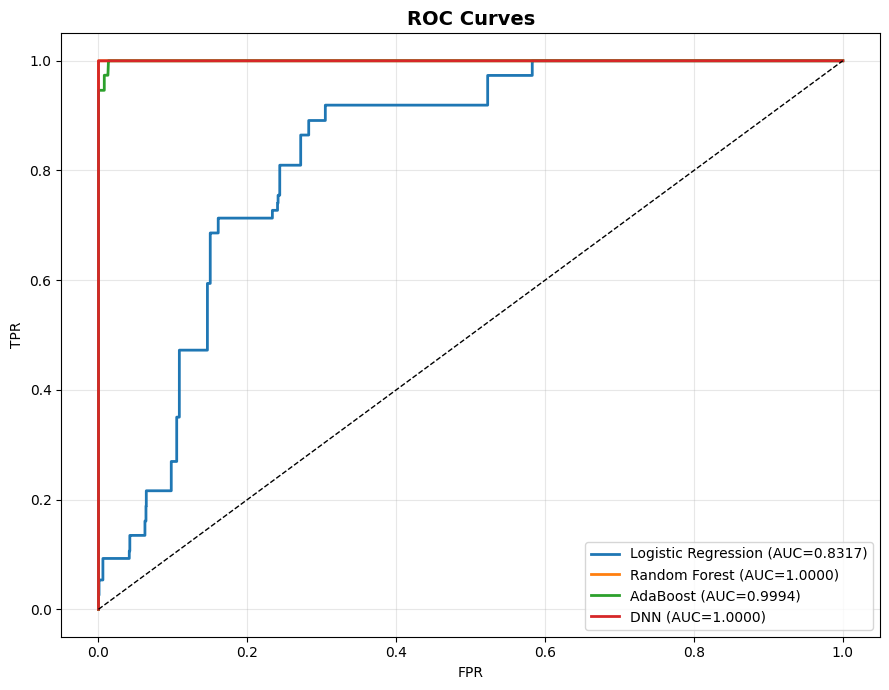

In [26]:
plt.figure(figsize=(9,7))
for n,v in results.items():
    fpr,tpr,_=roc_curve(y_test_b,v['y_probs'])
    plt.plot(fpr,tpr,lw=2,label=f"{n} (AUC={v['ROC-AUC']:.4f})")
plt.plot([0,1],[0,1],'k--',lw=1);plt.xlabel('FPR');plt.ylabel('TPR')
plt.title('ROC Curves',fontsize=14,weight='bold');plt.legend();plt.grid(alpha=0.3);plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,'roc_curves.png'),dpi=150);plt.show()

## Cell 14 — Confusion Matrices

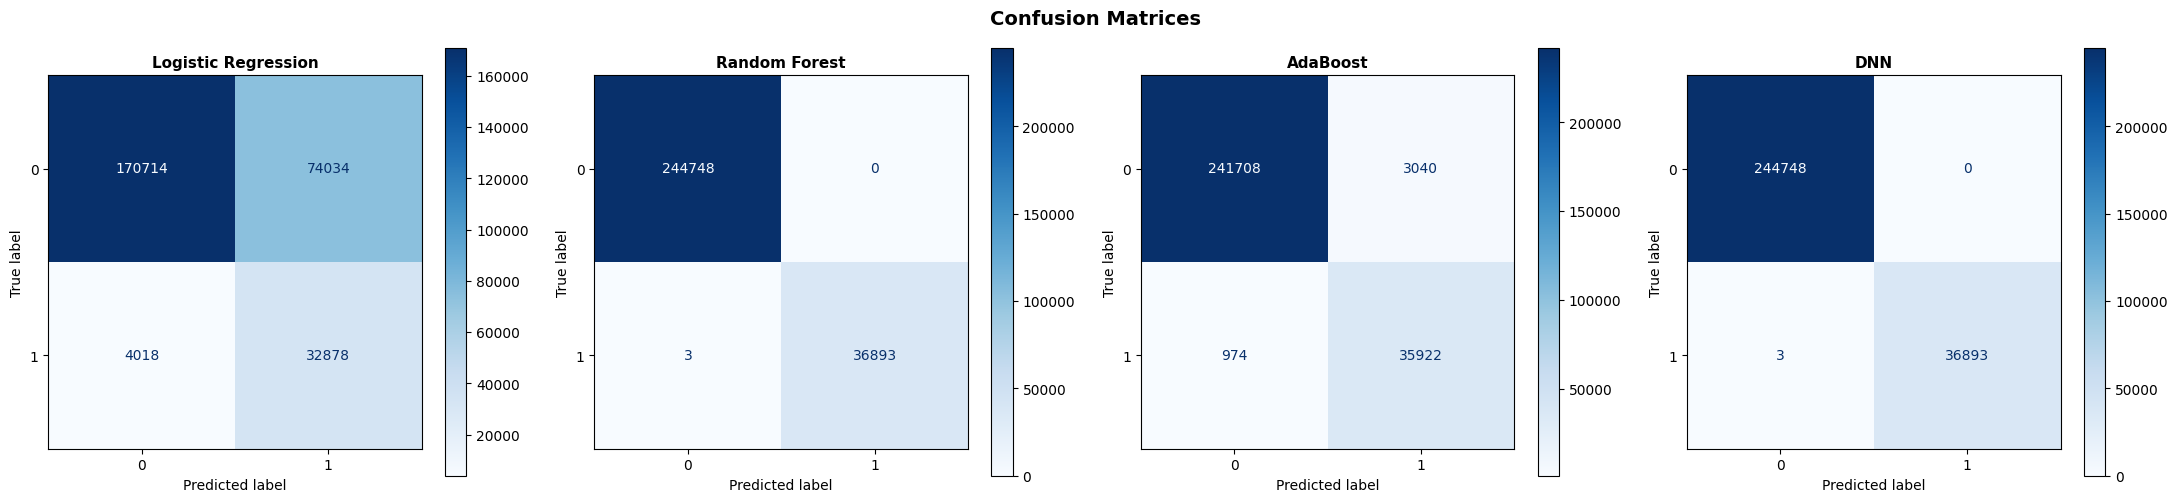

In [27]:
fig,axes=plt.subplots(1,4,figsize=(22,5))
for ax,(n,v) in zip(axes,results.items()):
    ConfusionMatrixDisplay.from_predictions(y_test_b,v['y_pred'],ax=ax,cmap='Blues')
    ax.set_title(n,fontsize=11,weight='bold')
fig.suptitle('Confusion Matrices',fontsize=14,weight='bold');plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,'confusion_matrices.png'),dpi=150);plt.show()

## Cell 15 — Bar Chart

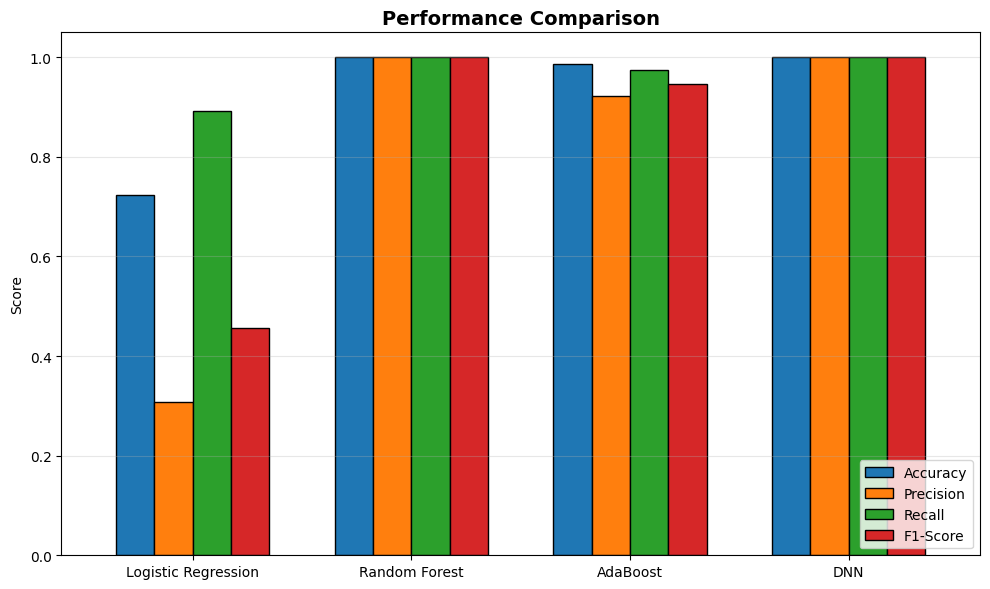

In [28]:
comparison_df[['Accuracy','Precision','Recall','F1-Score']].plot(kind='bar',figsize=(10,6),width=0.7,edgecolor='black')
plt.title('Performance Comparison',fontsize=14,weight='bold');plt.ylabel('Score');plt.ylim(0,1.05)
plt.xticks(rotation=0);plt.legend(loc='lower right');plt.grid(axis='y',alpha=0.3);plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,'performance_comparison.png'),dpi=150);plt.show()

---
## PART D — K-FOLD CROSS VALIDATION
---

## Cell 16 — 5-Fold CV

In [29]:
skf=StratifiedKFold(n_splits=5,shuffle=True,random_state=42);fold_metrics=[]
for fold,(ti,vi) in enumerate(skf.split(X_scaled,y_binary),1):
    Xtr,Xv=X_scaled.iloc[ti],X_scaled.iloc[vi];ytr,yv=y_binary.iloc[ti],y_binary.iloc[vi]
    Xtr_b,ytr_b=SMOTE(random_state=42).fit_resample(Xtr,ytr)
    rf_f=RandomForestClassifier(n_estimators=200,max_depth=20,random_state=42);rf_f.fit(Xtr_b,ytr_b)
    p=rf_f.predict(Xv)
    fold_metrics.append({'Fold':fold,'Accuracy':accuracy_score(yv,p),'Precision':precision_score(yv,p,zero_division=0),
        'Recall':recall_score(yv,p,zero_division=0),'F1-Score':f1_score(yv,p,zero_division=0)})
    print(f"Fold {fold}: Acc={fold_metrics[-1]['Accuracy']:.4f} F1={fold_metrics[-1]['F1-Score']:.4f}")
kfold_df=pd.DataFrame(fold_metrics)
display(kfold_df.set_index('Fold'))
display(kfold_df.drop(columns='Fold').mean().to_frame('Mean').T)

Fold 1: Acc=1.0000 F1=0.9999
Fold 2: Acc=1.0000 F1=1.0000
Fold 3: Acc=1.0000 F1=1.0000
Fold 4: Acc=1.0000 F1=0.9999
Fold 5: Acc=1.0000 F1=1.0000


,Accuracy,Precision,Recall,F1-Score
Fold,,,,
1,0.999986,1.0,0.999892,0.999946
2,0.999993,1.0,0.999946,0.999973
3,0.999996,1.0,0.999973,0.999986
4,0.999972,1.0,0.999783,0.999892
5,0.999989,1.0,0.999919,0.999959


,Accuracy,Precision,Recall,F1-Score
Mean,0.999987,1.0,0.999902,0.999951


---
## PART E — EXPLAINABLE AI
---

## Cell 17 — SHAP

<Figure size 1000x600 with 0 Axes>

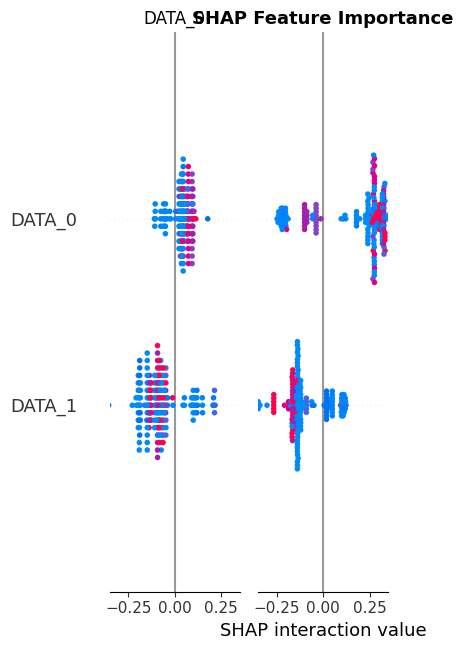

<Figure size 1000x600 with 0 Axes>

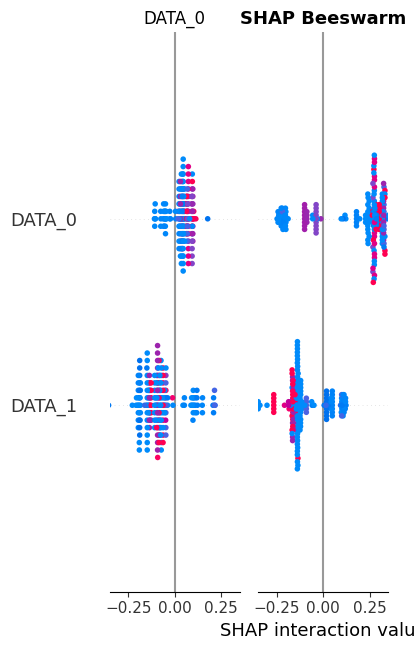

In [30]:
explainer_shap=shap.TreeExplainer(best_rf)
X_shap=X_test_b.sample(min(200,len(X_test_b)),random_state=42)
sv=explainer_shap.shap_values(X_shap)
sv=sv[1] if isinstance(sv,list) else sv
plt.figure(figsize=(10,6));shap.summary_plot(sv,X_shap,plot_type='bar',show=False)
plt.title('SHAP Feature Importance',fontsize=13,weight='bold');plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,'shap_bar.png'),dpi=150);plt.show()
plt.figure(figsize=(10,6));shap.summary_plot(sv,X_shap,show=False)
plt.title('SHAP Beeswarm',fontsize=13,weight='bold');plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR,'shap_beeswarm.png'),dpi=150);plt.show()

## Cell 18 — LIME

LIME explanations...


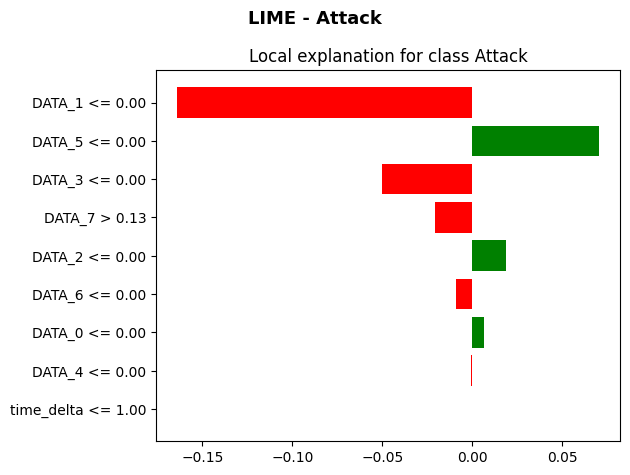

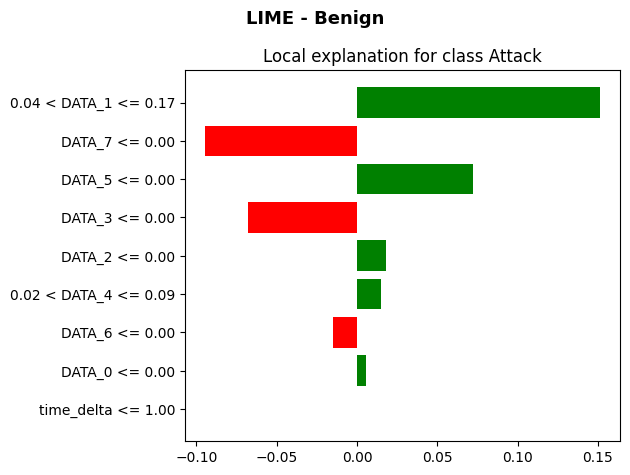

LIME plots saved.


In [31]:
print('LIME explanations...')
lime_exp=LimeTabularExplainer(X_train_bal.values if isinstance(X_train_bal,pd.DataFrame) else X_train_bal,
    feature_names=available,class_names=['Benign','Attack'],mode='classification')


X_test_reset = X_test_b.reset_index(drop=True)
y_test_reset = y_test_b.reset_index(drop=True)

for lbl,tgt in [('Attack',1),('Benign',0)]:
    mask = y_test_reset == tgt
    if mask.sum() == 0: continue
    row = X_test_reset[mask].iloc[0].values
    exp = lime_exp.explain_instance(row, best_rf.predict_proba, num_features=len(available))
    fig = exp.as_pyplot_figure()
    fig.suptitle(f'LIME - {lbl}', fontsize=13, weight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f'lime_{lbl.lower()}.png'), dpi=150)
    plt.show()
print('LIME plots saved.')

In [32]:

if 'specific_class' in df.columns:
    y_multi = df['specific_class'].copy()
    print("Using specific_class column")
elif 'source_file' in df.columns:
    y_multi = df['source_file'].copy()
    print("Using source_file column")
else:
    y_multi = df['attack_type'].copy()
    print("Using attack_type column")

print(f'Classes found: {y_multi.unique()}')

le = LabelEncoder()
y_multi_enc = le.fit_transform(y_multi)
class_names = le.classes_.tolist()
print(f'Encoded classes ({len(class_names)}): {class_names}')

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_scaled, y_multi_enc, test_size=0.2, random_state=42, stratify=y_multi_enc)
print(f'Train: {len(X_train_m):,}  Test: {len(X_test_m):,}')

Using source_file column
Classes found: ['benign' 'DoS' 'spoofing-GAS' 'spoofing-RPM' 'spoofing-SPEED'
 'spoofing-STEERING_WHEEL']
Encoded classes (6): ['DoS', 'benign', 'spoofing-GAS', 'spoofing-RPM', 'spoofing-SPEED', 'spoofing-STEERING_WHEEL']
Train: 1,126,575  Test: 281,644


---
## PART F — MULTI-CLASS (ALL 6 ATTACK TYPES)
---

## Cell 19 — Multi-Class RF

Classes: ['DoS', 'benign', 'spoofing-GAS', 'spoofing-RPM', 'spoofing-SPEED', 'spoofing-STEERING_WHEEL']
Smallest class has 7993 samples
After balancing: 5,873,934 samples

Multi-class Accuracy: 0.99648
                         precision    recall  f1-score   support

                    DoS       1.00      1.00      1.00     14933
                 benign       1.00      1.00      1.00    244748
           spoofing-GAS       1.00      1.00      1.00      1998
           spoofing-RPM       1.00      0.91      0.95     10980
         spoofing-SPEED       0.83      1.00      0.91      4990
spoofing-STEERING_WHEEL       1.00      1.00      1.00      3995

               accuracy                           1.00    281644
              macro avg       0.97      0.98      0.98    281644
           weighted avg       1.00      1.00      1.00    281644



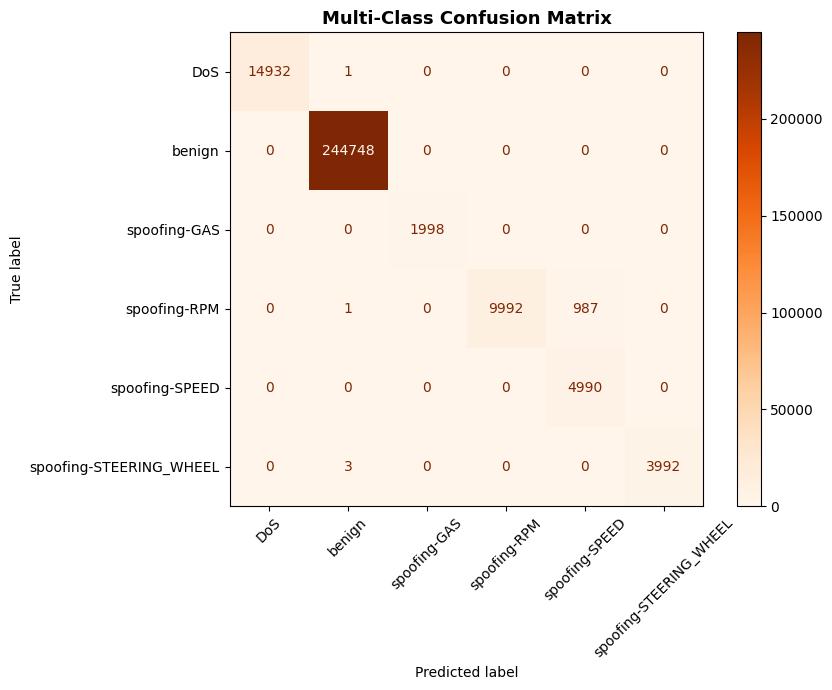


Classes in test data: ['DoS', 'benign', 'spoofing-GAS', 'spoofing-RPM', 'spoofing-SPEED', 'spoofing-STEERING_WHEEL']


In [33]:
print(f'Classes: {class_names}')

from imblearn.over_sampling import RandomOverSampler

min_samples = min([(y_train_m == i).sum() for i in range(len(class_names))])
print(f'Smallest class has {min_samples} samples')

if min_samples >= 7:
    X_m_bal, y_m_bal = SMOTE(random_state=42).fit_resample(X_train_m, y_train_m)
else:
    X_m_bal, y_m_bal = RandomOverSampler(random_state=42).fit_resample(X_train_m, y_train_m)

print(f'After balancing: {len(X_m_bal):,} samples')

rf_multi = RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42, n_jobs=-1)
rf_multi.fit(X_m_bal, y_m_bal)
y_pm = rf_multi.predict(X_test_m)

print(f'\nMulti-class Accuracy: {accuracy_score(y_test_m, y_pm):.5f}')


present_labels = sorted(set(y_test_m) | set(y_pm))
present_names = [class_names[i] for i in present_labels]

print(classification_report(y_test_m, y_pm, labels=present_labels, target_names=present_names))

fig, ax = plt.subplots(figsize=(9, 7))
ConfusionMatrixDisplay.from_predictions(y_test_m, y_pm, labels=present_labels, display_labels=present_names, ax=ax, cmap='Oranges', xticks_rotation=45)
ax.set_title('Multi-Class Confusion Matrix', fontsize=13, weight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'multiclass_cm.png'), dpi=150)
plt.show()

print(f'\nClasses in test data: {present_names}')

---
## PART G — MULTI-FORMAT COMPARISON
---

## Cell 20 — Decimal vs Hex vs Binary

Decimal: 3,588 rows, columns: ['ID', 'DATA_0', 'DATA_1', 'DATA_2', 'DATA_3']...
  Decimal: 3,588 samples, 9 features after cleaning
  Decimal: Acc=0.99861 Features=9
Hexadecimal: 3,591 rows, columns: ['Interface', 'ID', 'DATA_0', 'DATA_1', 'DATA_2']...
  Hexadecimal: 3,591 samples, 9 features after cleaning
  Hexadecimal: Acc=0.99861 Features=9
Binary: 3,588 rows, columns: ['ID0', 'ID1', 'ID2', 'ID3', 'ID4']...
  Binary: 3,588 samples, 75 features after cleaning
  Binary: Acc=0.99721 Features=75


,Accuracy,Precision,Recall,F1-Score,Features
Decimal,0.99861,1.00000,0.87500,0.93333,9.00000
Hexadecimal,0.99861,0.90000,1.00000,0.94737,9.00000
Binary,0.99721,1.00000,0.75000,0.85714,75.00000


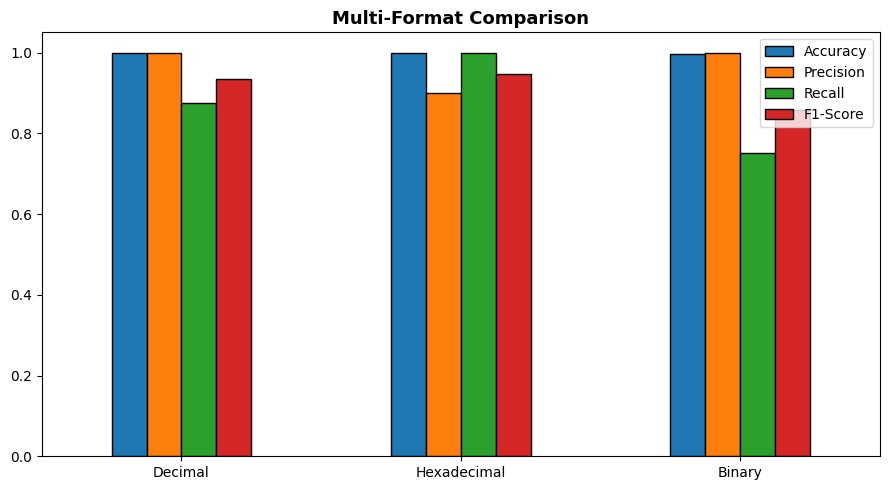

In [34]:
format_results = {}

def eval_format(name, path):
    if not os.path.isdir(path):
        print(f'{name}: NOT FOUND - SKIP')
        return
    frames = []
    for f in sorted(os.listdir(path)):
        if not f.endswith('.csv'): continue
        t = pd.read_csv(os.path.join(path, f))
        t['is_malicious'] = 0 if 'benign' in f.lower() else 1
        frames.append(t)
    data = pd.concat(frames, ignore_index=True)
    data.drop_duplicates(inplace=True)
    print(f'{name}: {len(data):,} rows, columns: {list(data.columns[:5])}...')


    skip = {'label','category','specific_class','is_malicious','source_file','attack_type','Timestamp','Time'}
    fc = [c for c in data.columns if c not in skip]

    Xf = data[fc].copy()
    yf = data['is_malicious'].copy()


    for col in Xf.columns:
        if Xf[col].dtype == object:

            converted = pd.to_numeric(Xf[col], errors='coerce')
            if converted.isna().sum() > len(Xf) * 0.5:

                try:
                    converted = Xf[col].apply(lambda v: int(str(v).strip(), 16) if isinstance(v, str) else v)
                    converted = pd.to_numeric(converted, errors='coerce')
                except:
                    pass
            Xf[col] = converted


    Xf = Xf.dropna(axis=1, how='all')
    Xf = Xf.fillna(0)


    non_const = Xf.columns[Xf.nunique() > 1].tolist()
    if len(non_const) < 2:
        print(f'  {name}: Not enough variable features - SKIP')
        return
    Xf = Xf[non_const]


    yf = yf.loc[Xf.index]

    print(f'  {name}: {len(Xf):,} samples, {len(non_const)} features after cleaning')

    if len(Xf) < 10:
        print(f'  {name}: Too few samples - SKIP')
        return

    scaler_f = MinMaxScaler()
    Xf_s = pd.DataFrame(scaler_f.fit_transform(Xf), columns=non_const)

    Xf_tr, Xf_te, yf_tr, yf_te = train_test_split(
        Xf_s, yf.reset_index(drop=True), test_size=0.2, random_state=42, stratify=yf.reset_index(drop=True))

    Xf_tr_b, yf_tr_b = SMOTE(random_state=42).fit_resample(Xf_tr, yf_tr)

    rf = RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42, n_jobs=-1)
    rf.fit(Xf_tr_b, yf_tr_b)
    yp = rf.predict(Xf_te)
    format_results[name] = {
        'Accuracy': accuracy_score(yf_te, yp),
        'Precision': precision_score(yf_te, yp, zero_division=0),
        'Recall': recall_score(yf_te, yp, zero_division=0),
        'F1-Score': f1_score(yf_te, yp, zero_division=0),
        'Features': len(non_const)
    }
    print(f'  {name}: Acc={format_results[name]["Accuracy"]:.5f} Features={len(non_const)}')

for n, p in [('Decimal', DECIMAL_PATH), ('Hexadecimal', HEX_PATH), ('Binary', BINARY_PATH)]:
    eval_format(n, p)

if format_results:
    fmt_df = pd.DataFrame(format_results).T
    display(fmt_df.style.format('{:.5f}').highlight_max(axis=0, color='#c6efce'))
    fmt_df[['Accuracy','Precision','Recall','F1-Score']].plot(kind='bar', figsize=(9,5), edgecolor='black')
    plt.title('Multi-Format Comparison', fontsize=13, weight='bold')
    plt.ylim(0, 1.05); plt.xticks(rotation=0); plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'format_comparison.png'), dpi=150); plt.show()

---
## PART H — EXPORT EVERYTHING
---

## Cell 21 — Save Models & Results

In [35]:
joblib.dump(best_rf,os.path.join(OUTPUT_DIR,'DriveGuardAI_RF_Model.pkl'))
joblib.dump(scaler,os.path.join(OUTPUT_DIR,'DriveGuardAI_Scaler.pkl'))
joblib.dump(le,os.path.join(OUTPUT_DIR,'DriveGuardAI_LabelEncoder.pkl'))
joblib.dump(rf_multi,os.path.join(OUTPUT_DIR,'DriveGuardAI_RF_MultiClass.pkl'))
dnn_model.save(os.path.join(OUTPUT_DIR,'DriveGuardAI_DNN.h5'))

export_results={}
for n,v in results.items():
    export_results[n]={k:round(float(v2),5) for k,v2 in v.items() if k not in ('y_probs','y_pred')}
with open(os.path.join(OUTPUT_DIR,'model_results.json'),'w') as f: json.dump(export_results,f,indent=2)
if format_results:
    with open(os.path.join(OUTPUT_DIR,'format_results.json'),'w') as f:
        json.dump({k:{kk:round(float(vv),5) for kk,vv in v.items()} for k,v in format_results.items()},f,indent=2)
kfold_df.to_csv(os.path.join(OUTPUT_DIR,'kfold_results.csv'),index=False)
comparison_df.to_csv(os.path.join(OUTPUT_DIR,'comparison_table.csv'))
with open(os.path.join(OUTPUT_DIR,'feature_names.json'),'w') as f: json.dump(available,f)
with open(os.path.join(OUTPUT_DIR,'class_names.json'),'w') as f: json.dump(class_names,f)
print('ALL SAVED to:',OUTPUT_DIR)
for fn in sorted(os.listdir(OUTPUT_DIR)): print(f'  {fn}')

ALL SAVED to: /content/drive/MyDrive/DriveGuardAI_Output
  DriveGuardAI_DNN.h5
  DriveGuardAI_Dashboard_nnn (1).html
  DriveGuardAI_LabelEncoder.pkl
  DriveGuardAI_RF_Model.pkl
  DriveGuardAI_RF_MultiClass.pkl
  DriveGuardAI_Scaler.pkl
  case_comparison.json
  class_names.json
  comparison_table.csv
  confusion_matrices.png
  feature_names.json
  format_comparison.png
  format_results.json
  kfold_results.csv
  lime_attack.png
  lime_benign.png
  model_results.json
  multiclass_cm.png
  performance_comparison.png
  roc_curves.png
  shap_bar.png
  shap_beeswarm.png
  نسخة من DriveGuardAI_DNN.h5
  نسخة من DriveGuardAI_Dashboard_nnn (1).html
  نسخة من DriveGuardAI_LabelEncoder.pkl
  نسخة من DriveGuardAI_RF_Model.pkl
  نسخة من DriveGuardAI_RF_MultiClass.pkl
  نسخة من DriveGuardAI_Scaler.pkl
  نسخة من case_comparison.json
  نسخة من class_names.json
  نسخة من comparison_table.csv
  نسخة من confusion_matrices.png
  نسخة من feature_names.json
  نسخة من format_comparison.png
  نسخة من format_re

In [44]:
from imblearn.over_sampling import SMOTE, RandomOverSampler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
import time

case_results = {}

def run_case(case_name, X_tr, y_tr, X_te, y_te):
    print(f'\n{"="*60}\n  {case_name}\n{"="*60}')
    print(f'  Train: {len(X_tr):,} | Test: {len(X_te):,}')
    print(f'  Train distribution: {dict(pd.Series(y_tr).value_counts())}')
    print(f'  Test distribution: {dict(pd.Series(y_te).value_counts())}')

    t0 = time.time()
    rf = RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42, n_jobs=-1)
    rf.fit(X_tr, y_tr)
    train_time = time.time() - t0

    t0 = time.time()
    y_pred = rf.predict(X_te)
    y_probs = rf.predict_proba(X_te)[:, 1]
    inference_time = ((time.time() - t0) / len(X_te)) * 1000

    acc = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec = recall_score(y_te, y_pred, zero_division=0)
    f1 = f1_score(y_te, y_pred, zero_division=0)
    f1_macro = f1_score(y_te, y_pred, average='macro', zero_division=0)
    try: roc = roc_auc_score(y_te, y_probs)
    except: roc = 0.0

    print(f'  Acc={acc:.5f} Prec={prec:.5f} Rec={rec:.5f} F1={f1:.5f} F1-Macro={f1_macro:.5f} AUC={roc:.5f}')

    return {
        'Accuracy': float(acc), 'Precision': float(prec), 'Recall': float(rec),
        'F1-Score': float(f1), 'F1-Macro': float(f1_macro), 'ROC-AUC': float(roc),
        'Train Time (s)': round(train_time, 2),
        'Inference Latency (ms/sample)': round(inference_time, 4),
        'Train Samples': len(X_tr), 'Test Samples': len(X_te)
    }

# CASE 1: Full data + SMOTE (use existing Random Forest results)
print('[CASE 1] Using existing Random Forest results')
# Compute F1-Macro for Case 1 from existing predictions
y_pred_c1 = best_rf.predict(X_test_b)
f1_macro_c1 = f1_score(y_test_b, y_pred_c1, average='macro', zero_division=0)

case_results['Case 1: Full Data + SMOTE'] = {
    'Accuracy': float(results['Random Forest']['Accuracy']),
    'Precision': float(results['Random Forest']['Precision']),
    'Recall': float(results['Random Forest']['Recall']),
    'F1-Score': float(results['Random Forest']['F1-Score']),
    'F1-Macro': float(f1_macro_c1),
    'ROC-AUC': float(results['Random Forest']['ROC-AUC']),
    'Train Time (s)': float(results['Random Forest']['Train Time (s)']),
    'Inference Latency (ms/sample)': float(results['Random Forest']['Inference Latency (ms/sample)']),
    'Train Samples': len(X_train_bal),
    'Test Samples': len(X_test_b)
}
print(f'  Case 1 F1-Macro = {f1_macro_c1:.5f}')

# Deduplicate dataset for Cases 2 and 3
dedup_cols = ['DATA_0','DATA_1','DATA_2','DATA_3','DATA_4','DATA_5','DATA_6','DATA_7']
df_dedup = df.drop_duplicates(subset=dedup_cols + ['is_malicious']).reset_index(drop=True)
print(f'\nDeduplicated: {len(df):,} -> {len(df_dedup):,} rows')
print(f'Class distribution:\n{df_dedup["is_malicious"].value_counts()}')

X_dedup = df_dedup[available].copy()
y_dedup = df_dedup['is_malicious'].copy()
X_dedup_scaled = pd.DataFrame(scaler.transform(X_dedup), columns=available)

min_class = y_dedup.value_counts().min()
if min_class >= 2:
    X_d_tr, X_d_te, y_d_tr, y_d_te = train_test_split(
        X_dedup_scaled, y_dedup, test_size=0.3, random_state=42, stratify=y_dedup)
else:
    X_d_tr, X_d_te, y_d_tr, y_d_te = train_test_split(
        X_dedup_scaled, y_dedup, test_size=0.3, random_state=42)

# CASE 2: Dedup + SMOTE
print('\n[CASE 2] Deduplicated + SMOTE')
print(f'Original train: {dict(pd.Series(y_d_tr).value_counts())}')
try:
    k = min(5, max(1, pd.Series(y_d_tr).value_counts().min() - 1))
    X_d_bal, y_d_bal = SMOTE(random_state=42, k_neighbors=k).fit_resample(X_d_tr, y_d_tr)
    print(f'After SMOTE: {dict(pd.Series(y_d_bal).value_counts())}')
except Exception as e:
    print(f'SMOTE failed ({e}), using RandomOverSampler')
    X_d_bal, y_d_bal = RandomOverSampler(random_state=42).fit_resample(X_d_tr, y_d_tr)
    print(f'After ROS: {dict(pd.Series(y_d_bal).value_counts())}')

case_results['Case 2: Dedup + SMOTE'] = run_case(
    'CASE 2: Deduplicated + SMOTE', X_d_bal, y_d_bal, X_d_te, y_d_te)

# CASE 3: Dedup, NO SMOTE (honest version - same model, no balancing)
case_results['Case 3: Dedup, No SMOTE'] = run_case(
    'CASE 3: Deduplicated, No SMOTE', X_d_tr, y_d_tr, X_d_te, y_d_te)

# Final comparison
print('\n' + '='*80)
print('  3-CASE COMPARISON SUMMARY')
print('='*80)
for name, v in case_results.items():
    print(f'\n{name}')
    print(f"  Accuracy:  {v['Accuracy']:.5f}")
    print(f"  F1-Score:  {v['F1-Score']:.5f}")
    print(f"  F1-Macro:  {v['F1-Macro']:.5f}  <-- exposes the accuracy trap")
    print(f"  ROC-AUC:   {v['ROC-AUC']:.5f}")

print('\nDone. Restart your bottom Cell 22 to update the dashboard.')

[CASE 1] Using existing Random Forest results
  Case 1 F1-Macro = 0.99998

Deduplicated: 1,408,219 -> 3,576 rows
Class distribution:
is_malicious
0    3538
1      38
Name: count, dtype: int64

[CASE 2] Deduplicated + SMOTE
Original train: {0: np.int64(2476), 1: np.int64(27)}
After SMOTE: {0: np.int64(2476), 1: np.int64(2476)}

  CASE 2: Deduplicated + SMOTE
  Train: 4,952 | Test: 1,073
  Train distribution: {0: np.int64(2476), 1: np.int64(2476)}
  Test distribution: {0: np.int64(1062), 1: np.int64(11)}
  Acc=0.99627 Prec=1.00000 Rec=0.63636 F1=0.77778 F1-Macro=0.88795 AUC=0.99568

  CASE 3: Deduplicated, No SMOTE
  Train: 2,503 | Test: 1,073
  Train distribution: {0: np.int64(2476), 1: np.int64(27)}
  Test distribution: {0: np.int64(1062), 1: np.int64(11)}
  Acc=0.99534 Prec=1.00000 Rec=0.54545 F1=0.70588 F1-Macro=0.85177 AUC=0.99388

  3-CASE COMPARISON SUMMARY

Case 1: Full Data + SMOTE
  Accuracy:  0.99999
  F1-Score:  0.99996
  F1-Macro:  0.99998  <-- exposes the accuracy trap
  RO

In [45]:
!pip install flask flask-cors pyngrok

In [46]:
!ngrok authtoken 3Brs5ZG7Qot88XACJVChaAXuPnt_VTCYwbnBA2cTXcGCdBno

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


---
## PART I — LIVE DASHBOARD WITH REAL MODEL
---
This runs a Flask API server inside Colab that serves your **actual trained model**. The dashboard connects to it, so every classification is real.

## Cell 22 — Start Flask API Server + Dashboard

In [47]:


!pip install flask flask-cors -q

from flask import Flask, request, jsonify, Response
from flask_cors import CORS
import threading, subprocess, re, time

app = Flask(__name__)
CORS(app, resources={r"/*": {"origins": "*"}})

print(f'Classes: {class_names}')

@app.route('/')
def index():
    try:
        with open('/content/drive/MyDrive/DriveGuardAI_Output/DriveGuardAI_Dashboard.html','r') as f:
            return Response(f.read(), mimetype='text/html')
    except:
        return '<h1>Upload DriveGuardAI_Dashboard.html to DriveGuardAI_Output folder</h1>'

@app.route('/api/predict', methods=['POST','OPTIONS'])
def predict_route():
    if request.method == 'OPTIONS':
        return '', 204
    try:
        data = request.get_json()
        features = data.get('features', [])
        use_scaled = data.get('scaled', False)
        arr = np.array(features, dtype=float).reshape(1, -1)
        scaled = arr if use_scaled else scaler.transform(arr)
        prob = float(best_rf.predict_proba(scaled)[:, 1][0])
        is_attack = prob >= 0.25
        multi_pred = int(rf_multi.predict(scaled)[0])
        attack_name = str(le.inverse_transform([multi_pred])[0])
        t0 = time.time()
        _ = best_rf.predict(scaled)
        latency = round((time.time() - t0) * 1000, 4)
        return jsonify({
            'is_attack': bool(is_attack),
            'probability': round(prob, 4),
            'attack_type': attack_name,
            'latency_ms': latency
        })
    except Exception as e:
        return jsonify({'error': str(e)}), 400

@app.route('/api/results')
def results_route():
    export = {}
    for n, v in results.items():
        export[n] = {k: round(float(v2), 5) for k, v2 in v.items() if k not in ('y_probs', 'y_pred')}
    fmt = {}
    if format_results:
        for k, v in format_results.items():
            fmt[k] = {kk: round(float(vv), 5) for kk, vv in v.items()}
    kf = kfold_df.to_dict('records') if 'kfold_df' in dir() else []

    cases = {}
    if 'case_results' in dir():
        for k, v in case_results.items():
            cases[k] = {kk: (float(vv) if isinstance(vv, (int, float, np.floating, np.integer)) else vv)
                        for kk, vv in v.items()}

    return jsonify({
        'models': export,
        'formats': fmt,
        'kfold': kf,
        'cases': cases,
        'class_names': class_names
    })

@app.route('/api/test_samples')
def samples_route():
    samps = []
    for ci, cn in enumerate(class_names):
        mask = y_test_m == ci
        idxs = np.where(mask)[0]
        for i in range(min(3, len(idxs))):
            row_s = X_test_m.iloc[idxs[i]].values.tolist()
            raw = scaler.inverse_transform([row_s])[0].tolist()
            samps.append({'features': raw, 'features_scaled': row_s, 'type': str(cn)})
    return jsonify(samps)

def run():
    app.run(port=5001, use_reloader=False)

threading.Thread(target=run, daemon=True).start()
time.sleep(2)
print('Flask server running on port 5001\n')

# Cloudflare Tunnel (faster than ngrok, no account needed)
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O cloudflared
!chmod +x cloudflared

print('Starting Cloudflare Tunnel...\n')
proc = subprocess.Popen(
    ['./cloudflared', 'tunnel', '--url', 'http://localhost:5001'],
    stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1
)

public_url = None
start_time = time.time()
for line in iter(proc.stdout.readline, ''):
    print(line, end='')
    match = re.search(r'(https://[a-z0-9-]+\.trycloudflare\.com)', line)
    if match:
        public_url = match.group(1)
        break
    if time.time() - start_time > 30:
        break

if public_url:
    print(f'\n{"="*60}')
    print(f'  OPEN THIS URL:')
    print(f'  {public_url}')
    print(f'{"="*60}')
    print(f'  Login: admin / admin123')
    print(f'  API URL field: {public_url}')
else:
    print('Could not get URL. Look above for trycloudflare.com link.')


Classes: ['DoS', 'benign', 'spoofing-GAS', 'spoofing-RPM', 'spoofing-SPEED', 'spoofing-STEERING_WHEEL']
 * Serving Flask app '__main__'
 * Debug mode: off


Address already in use
Port 5001 is in use by another program. Either identify and stop that program, or start the server with a different port.


Flask server running on port 5001

cloudflared: Text file busy
Starting Cloudflare Tunnel...

2026-05-24T16:07:19Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-05-24T16:07:19Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-05-24T16:07:23Z INF +--------------------------------------------------------------------------------------------+
2026-05-24T16:07:23Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be re

In [48]:

print('='*70)
print('  REAL MODEL ACCURACY TEST - 20 Random Test Samples')
print('='*70)

correct = 0
total_test = 20
random_indices = np.random.RandomState(99).choice(len(X_test_b), total_test, replace=False)

for idx in random_indices:
    row = X_test_b.iloc[idx].values.reshape(1, -1)
    actual = int(y_test_b.iloc[idx])

    prob = best_rf.predict_proba(row)[:, 1][0]
    pred = 1 if prob >= 0.25 else 0

    multi_pred = rf_multi.predict(row)[0]
    attack_name = le.inverse_transform([multi_pred])[0]

    actual_name = 'Attack' if actual == 1 else 'Benign'
    pred_name = 'Attack' if pred == 1 else 'Benign'
    match = 'CORRECT' if pred == actual else 'WRONG'
    color = match == 'CORRECT'

    print(f'  Sample: Prob={prob:.4f} | Pred={pred_name:7s} | Actual={actual_name:7s} | Type={attack_name:20s} | {match}')
    if pred == actual:
        correct += 1

print(f'\n  RESULT: {correct}/{total_test} correct ({correct/total_test*100:.1f}%)')
print('='*70)

  REAL MODEL ACCURACY TEST - 20 Random Test Samples
  Sample: Prob=0.0000 | Pred=Benign  | Actual=Benign  | Type=benign               | CORRECT
  Sample: Prob=0.0000 | Pred=Benign  | Actual=Benign  | Type=benign               | CORRECT
  Sample: Prob=0.0000 | Pred=Benign  | Actual=Benign  | Type=benign               | CORRECT
  Sample: Prob=0.0000 | Pred=Benign  | Actual=Benign  | Type=benign               | CORRECT
  Sample: Prob=0.0000 | Pred=Benign  | Actual=Benign  | Type=benign               | CORRECT
  Sample: Prob=0.0000 | Pred=Benign  | Actual=Benign  | Type=benign               | CORRECT
  Sample: Prob=0.0000 | Pred=Benign  | Actual=Benign  | Type=benign               | CORRECT
  Sample: Prob=0.0000 | Pred=Benign  | Actual=Benign  | Type=benign               | CORRECT
  Sample: Prob=0.0000 | Pred=Benign  | Actual=Benign  | Type=benign               | CORRECT
  Sample: Prob=0.0000 | Pred=Benign  | Actual=Benign  | Type=benign               | CORRECT
  Sample: Prob=0.0000 | Pred

In [49]:

y_pred_full = best_rf.predict(X_test_b)
full_acc = accuracy_score(y_test_b, y_pred_full)
print(f'Full test set accuracy: {full_acc:.6f}')
print(f'Total test samples: {len(y_test_b):,}')
print(f'Correct predictions: {(y_pred_full == y_test_b).sum():,}')
print(f'Wrong predictions: {(y_pred_full != y_test_b).sum():,}')

Full test set accuracy: 0.999989
Total test samples: 281,644
Correct predictions: 281,641
Wrong predictions: 3


In [50]:
print('case_results exists:', 'case_results' in dir())
if 'case_results' in dir():
    print(f'Cases: {list(case_results.keys())}')
    print(f'Sample: {case_results[list(case_results.keys())[0]]}')

case_results exists: True
Cases: ['Case 1: Full Data + SMOTE', 'Case 2: Dedup + SMOTE', 'Case 3: Dedup, No SMOTE']
Sample: {'Accuracy': 0.9999893482552442, 'Precision': 1.0, 'Recall': 0.9999186903729401, 'F1-Score': 0.9999593435335891, 'F1-Macro': 0.9999766074091554, 'ROC-AUC': 0.9999989295944467, 'Train Time (s)': 16.46, 'Inference Latency (ms/sample)': 0.0095, 'Train Samples': 347598, 'Test Samples': 281644}


In [51]:
!pip install flask flask-cors -q

from flask import Flask, request, jsonify, Response
from flask_cors import CORS
import threading, subprocess, re, time

app = Flask(__name__)
CORS(app, resources={r"/*": {"origins": "*"}})

@app.route('/')
def index():
    try:
        with open('/content/drive/MyDrive/DriveGuardAI_Output/DriveGuardAI_Dashboard.html','r') as f:
            return Response(f.read(), mimetype='text/html')
    except:
        return '<h1>Upload dashboard HTML to DriveGuardAI_Output folder</h1>'

@app.route('/api/predict', methods=['POST','OPTIONS'])
def predict_route():
    if request.method == 'OPTIONS':
        return '', 204
    try:
        data = request.get_json()
        features = data.get('features', [])
        arr = np.array(features, dtype=float).reshape(1, -1)
        scaled = scaler.transform(arr)
        prob = float(best_rf.predict_proba(scaled)[:, 1][0])
        is_attack = prob >= 0.25
        multi_pred = int(rf_multi.predict(scaled)[0])
        attack_name = str(le.inverse_transform([multi_pred])[0])
        t0 = time.time()
        _ = best_rf.predict(scaled)
        latency = round((time.time() - t0) * 1000, 4)
        return jsonify({'is_attack': bool(is_attack),'probability': round(prob, 4),
                        'attack_type': attack_name,'latency_ms': latency})
    except Exception as e:
        return jsonify({'error': str(e)}), 400

@app.route('/api/results')
def results_route():
    g = globals()
    export = {}
    for n, v in g.get('results', {}).items():
        export[n] = {k: round(float(v2), 5) for k, v2 in v.items() if k not in ('y_probs', 'y_pred')}
    fmt = {}
    for k, v in g.get('format_results', {}).items():
        fmt[k] = {kk: round(float(vv), 5) for kk, vv in v.items()}
    kf = g['kfold_df'].to_dict('records') if 'kfold_df' in g else []

    # READ case_results FROM GLOBALS AT REQUEST TIME (not startup)
    cases = {}
    if 'case_results' in g:
        for k, v in g['case_results'].items():
            cases[k] = {kk: (float(vv) if isinstance(vv, (int, float, np.floating, np.integer)) else vv)
                        for kk, vv in v.items()}
    print(f'[API] /api/results - Sending {len(cases)} cases')  # DEBUG

    return jsonify({'models': export,'formats': fmt,'kfold': kf,'cases': cases,'class_names': g.get('class_names', [])})

@app.route('/api/test_samples')
def samples_route():
    g = globals()
    samps = []
    for ci, cn in enumerate(g['class_names']):
        mask = g['y_test_m'] == ci
        idxs = np.where(mask)[0]
        for i in range(min(3, len(idxs))):
            row_s = g['X_test_m'].iloc[idxs[i]].values.tolist()
            raw = g['scaler'].inverse_transform([row_s])[0].tolist()
            samps.append({'features': raw,'features_scaled': row_s,'type': str(cn)})
    return jsonify(samps)

def run():
    app.run(port=5002, use_reloader=False)

threading.Thread(target=run, daemon=True).start()
time.sleep(2)
print('Flask running on port 5002')

# Check case_results visibility
print(f'case_results in globals: {"case_results" in globals()}')
if 'case_results' in globals():
    print(f'Cases: {list(case_results.keys())}')

!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O cloudflared
!chmod +x cloudflared

print('\nStarting Cloudflare Tunnel...\n')
proc = subprocess.Popen(['./cloudflared', 'tunnel', '--url', 'http://localhost:5002'],
                        stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1)

public_url = None
start_time = time.time()
for line in iter(proc.stdout.readline, ''):
    print(line, end='')
    match = re.search(r'(https://[a-z0-9-]+\.trycloudflare\.com)', line)
    if match:
        public_url = match.group(1)
        break
    if time.time() - start_time > 30:
        break

if public_url:
    print(f'\n{"="*60}\n  URL: {public_url}\n{"="*60}')
    print(f'  Login: admin / admin123\n  API: {public_url}')

 * Serving Flask app '__main__'
 * Debug mode: off


Address already in use
Port 5002 is in use by another program. Either identify and stop that program, or start the server with a different port.


Flask running on port 5002
case_results in globals: True
Cases: ['Case 1: Full Data + SMOTE', 'Case 2: Dedup + SMOTE', 'Case 3: Dedup, No SMOTE']
cloudflared: Text file busy

Starting Cloudflare Tunnel...

2026-05-24T16:08:00Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-05-24T16:08:00Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-05-24T16:08:05Z INF +-----------------------------------------------------------------------------------------